# RadarScenes Object Classification: From Single Scan to Multi-Scan Tracks

## Abstract

A single RadarScenes detection instance (one object, one scan) averages only ~2.9
points. A DeepReflecs point-set classifier trained on single scans (all 4 sensors)
scored 0.7370 macro F1 across the five target classes (`car`, `large_vehicle`,
`two_wheeler`, `pedestrian`, `pedestrian_group`), a sparsity ceiling, not a model
capacity one. That motivates accumulating a tracked object's points across its last
N radar scans instead of classifying each scan in isolation.

A naive pooled baseline (DeepReflecs, N=20 scans, all sensors, no notion of scan
order at all) already reaches 0.8613 macro F1 purely from extra points.
The best result (0.8897 macro F1) comes from a causal GRU that consumes the sequence of
per-scan embeddings directly (order-aware, one hidden state per track); fusing it with
the order-blind pooled embedding through a small trained classifier head adds only
+0.0002, within this project's own single-split noise band, not a reliable additional
gain. The full pipeline is shown in Figure 1.

The fusion model's confusion matrix shows two dominant error axes: 15% of
`large_vehicle` tracks get misclassified as `car` (the reverse barely happens, 3.8%),
and `pedestrian`/`pedestrian_group` confuse each other in both directions (6.6% and
8.6%).

![Multi-scan pipeline: FIFO buffer, DeepReflecs encoder, GRU](../pipeline_overview.png)


**Figure 1.** Multi-scan pipeline: per-track FIFO buffer feeding a frozen DeepReflecs encoder, whose per-scan embeddings drive a causal GRU.

## 1. The RadarScenes dataset

[RadarScenes](https://radar-scenes.com/) (Schumann et al., *RadarScenes: A Real-World
Radar Point Cloud Data Set for Automotive Applications*, arXiv:2104.02493, 2021) is a
real-world automotive radar dataset: 4 series-production radar sensors mounted on a
test vehicle, overlapping fields of view (Figure 2), point-level semantic labels
propagated from camera-verified object tracks.

![RadarScenes sensor layout, sensor 2 highlighted](../results/radarscenes_sensor_layout.png)

This project's taxonomy merges RadarScenes' own finer-grained labels into 5 classes
(`car`, `large_vehicle`, `two_wheeler`, `pedestrian`, `pedestrian_group`); `large_vehicle`
folds in `truck`/`train`/`bus` (near-chance pairwise separability from `car`-sized
vehicles at the raw-class level, and `train`/`bus` individually too thin to split
without leakage). All 4 sensors share one global clock.


**Figure 2.** RadarScenes sensor layout, sensor 2 highlighted.

## 2. Single-scan baseline: DeepReflecs

DeepReflecs (Ulrich, Glaser & Timm, *DeepReflecs: Deep Learning for Automotive Object
Classification with Radar Reflections*, IEEE RadarConf 2021,
[arXiv:2010.09273](https://arxiv.org/abs/2010.09273)) is a per-point shared-weight
network (PointNet-style): the same small MLP processes every point independently, so
the model is order-invariant and works on a variable number of points by
construction. This project adapts its input features to what RadarScenes provides (`x_rel`, `y_rel`,
`rcs`, `vr_compensated`, `range_sc`), not a literal reproduction of the paper's own
feature set.

What sets it apart from a plain PointNet baseline: the **global context layer** sits
*between* the two per-point stages, not only at the very end, so the second per-point
layer already has access to a permutation-invariant summary (mean/max) of the whole
point set before producing its own output. A **masked global max-pool** then reduces
the (variable-length) point set to one fixed embedding, invariant to how many padding points get added,
picking out the most salient reading per channel regardless of point count (Figure 3).

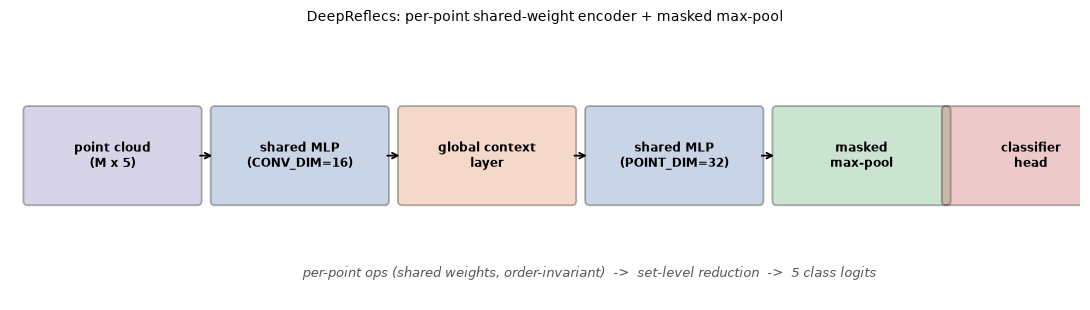

In [1]:

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(11, 3.2))
ax.set_xlim(0, 12)
ax.set_ylim(0, 3)
ax.axis("off")

stages = [
    (0.2, 1.6, "point cloud\n(M x 5)", "#8172B2"),
    (2.3, 1.6, "shared MLP\n(CONV_DIM=16)", "#4C72B0"),
    (4.4, 1.6, "global context\nlayer", "#DD8452"),
    (6.5, 1.6, "shared MLP\n(POINT_DIM=32)", "#4C72B0"),
    (8.6, 1.6, "masked\nmax-pool", "#55A868"),
    (10.5, 1.6, "classifier\nhead", "#C44E52"),
]
w, h = 1.9, 1.0
for x, y, label, color in stages:
    ax.add_patch(mpatches.FancyBboxPatch((x, y - h / 2), w, h, boxstyle="round,pad=0.05",
                                           linewidth=1.3, edgecolor="k", facecolor=color, alpha=0.3))
    ax.text(x + w / 2, y, label, ha="center", va="center", fontsize=8.5, fontweight="bold")

for (x1, y1, _, _), (x2, y2, _, _) in zip(stages[:-1], stages[1:]):
    ax.annotate("", xy=(x2, y2), xytext=(x1 + w, y1), arrowprops=dict(arrowstyle="->", color="k", lw=1.3))

ax.text(6.5, 0.3, "per-point ops (shared weights, order-invariant)  ->  set-level reduction  ->  5 class logits",
        ha="center", va="center", fontsize=9, style="italic", color="#555")
ax.set_title("DeepReflecs: per-point shared-weight encoder + masked max-pool", fontsize=10)
fig.tight_layout()
plt.show()


**Figure 3.** DeepReflecs: two per-point shared-weight MLP stages with a global context layer between them, followed by a masked max pool and classifier head.

car                    0.942     0.816     0.874     76572
large_vehicle          0.676     0.782     0.725     15555
two_wheeler            0.522     0.777     0.625     11466
pedestrian             0.664     0.884     0.758     35091
pedestrian_group       0.810     0.621     0.703     40081

macro F1: 0.7370


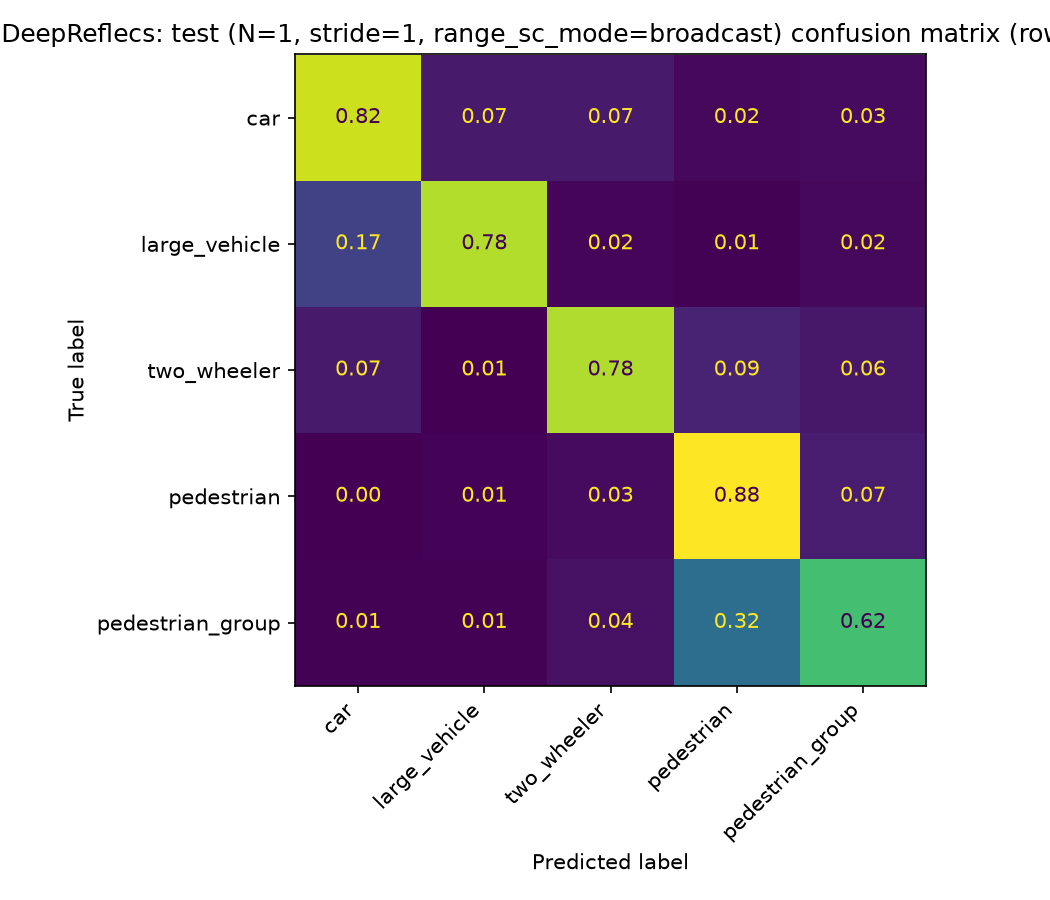

In [2]:

import json
from pathlib import Path
from IPython.display import Image, display

RESULTS = Path("/home/bruno/radar_machine_learning_ws/results")

metrics = json.loads((RESULTS / "track_accumulation/N1_stride1_allsensors/deepreflecs_test_metrics.json").read_text())
macro_f1 = sum(m["f1"] for m in metrics.values()) / len(metrics)
for c, m in metrics.items():
    print(f"{c:<18}{m['precision']:>10.3f}{m['recall']:>10.3f}{m['f1']:>10.3f}{m['support']:>10}")
print(f"\nmacro F1: {macro_f1:.4f}")

display(Image(filename=str(RESULTS / "track_accumulation/N1_stride1_allsensors/deepreflecs_test_confusion_matrix.png")))


**Figure 4.** Single-scan (N=1, all sensors) confusion matrix, row-normalized.

**Single-scan baseline: macro F1 = 0.7370.** `car` is the strongest class (F1
0.874, most points per instance, most rigid/consistent signature); `two_wheeler` is
the weakest (F1 0.625, sparsest class, easily confused with `car`/`pedestrian` at
this point-count regime). This is the floor every multi-scan result below improves
on (Figure 4).

## 3. Motivation: why accumulate scans

- A single detection instance averaging ~2.9 points hits a hard ceiling regardless of
  encoder: histograms, explicit per-instance statistics (median, max, min, spread), and DeepReflecs' learned
  point-set network all converge to a similar macro F1 band on single-scan data
  (Section 2). The bottleneck is point count, not model choice.
- Beyond raw point count, a tracked object's radar signature evolves scan to scan:
  a pedestrian's micro-Doppler shifts as limbs swing, and RCS fluctuates as an
  object's dominant reflectors change with aspect angle. None of that is visible in
  a single scan, motivating a sequence model over the per-scan embeddings (Section 5)
  in addition to simply pooling more points.
- A `track_id` persists across a tracked object's lifetime, multiple radar scans of
  the *same* object, and all 4 sensors share one global clock. Pooling a track's last
  N scans' points into one decision, instead of one scan's points, attacks sparsity
  directly at the input level rather than trying to encode more out of the same few
  points.
- A second, independent factor: building a window from whichever sensor(s) are
  actually detecting the track *right now* (cross-sensor handoff) gets more real
  detections per track without needing more real time to pass, since a track is
  often seen by 2-3 different sensors as it moves through overlapping fields of
  view.
- Coordinate frame: the car frame (`x_cc`/`y_cc`) rotates with ego heading and is unusable across scans; the
  global odometry-corrected frame (`x_seq`/`y_seq`), recentered per scan on that
  scan's own object centroid (`x_rel`/`y_rel` = `x_seq`/`y_seq` minus that scan's
  own mean), is what actually goes into the model, bounded scan-to-scan instead of
  drifting with the object's accumulated path.

## 4. Multi-scan baseline: naive pooling

All points from a track's last `N=20` scans (all sensors) concatenated into **one**
point set, classified by a single DeepReflecs instance trained end-to-end on the
pooled data. No sequence model, no per-scan structure retained, no notion of which
point came from which scan at all.

In deployment this window is a per-track FIFO buffer: each new scan pushes in and
the oldest one drops out, so the buffer always holds exactly the last N scans and a
decision fires the moment a new scan arrives (Figure 5).

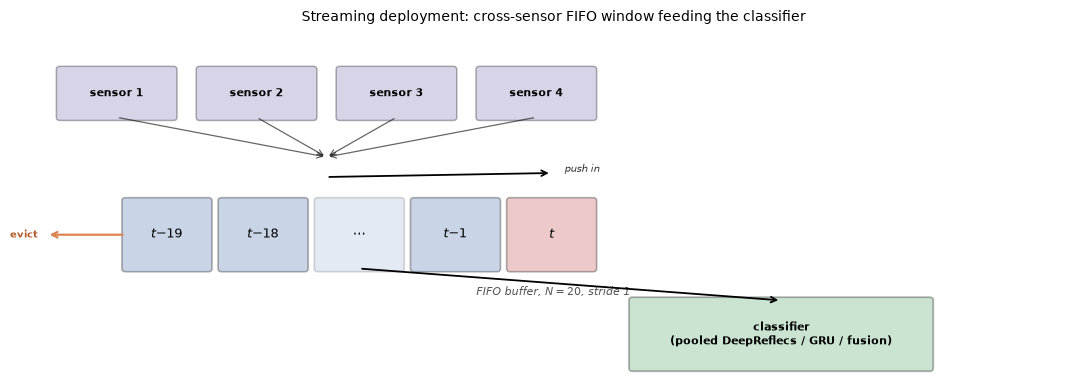

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(11, 4.0))
ax.set_xlim(0, 12)
ax.set_ylim(0, 4.3)
ax.axis("off")

# 4 sensors feeding in
sensor_xs = [1.0, 2.6, 4.2, 5.8]
w_sens, h_sens = 1.3, 0.6
sens_y = 3.3
for i, x in enumerate(sensor_xs):
    ax.add_patch(mpatches.FancyBboxPatch((x - w_sens / 2, sens_y), w_sens, h_sens, boxstyle="round,pad=0.04",
                                          linewidth=1.1, edgecolor="k", facecolor="#8172B2", alpha=0.3))
    ax.text(x, sens_y + h_sens / 2, f"sensor {i + 1}", ha="center", va="center", fontsize=7.8, fontweight="bold")

merge_x, merge_y = 3.4, 2.55
for x in sensor_xs:
    ax.annotate("", xy=(merge_x, merge_y + 0.25), xytext=(x, sens_y),
                arrowprops=dict(arrowstyle="->", color="k", lw=0.9, alpha=0.6))

# FIFO buffer: last N=20 scans, oldest (left) evicted as newest (right) arrives
buf_y = 1.4
buf_w, buf_h = 0.95, 0.85
buf_labels = ["$t{-}19$", "$t{-}18$", "$\\cdots$", "$t{-}1$", "$t$"]
n_slots = len(buf_labels)
buf_x0 = 1.1
xs_buf = [buf_x0 + i * (buf_w + 0.15) for i in range(n_slots)]

for x, label in zip(xs_buf, buf_labels):
    is_ellipsis = label == "$\\cdots$"
    is_newest = label == "$t$"
    color = "#C44E52" if is_newest else "#4C72B0"
    ax.add_patch(mpatches.FancyBboxPatch((x, buf_y), buf_w, buf_h, boxstyle="round,pad=0.04",
                                          linewidth=1.2, edgecolor="k", facecolor=color,
                                          alpha=0.15 if is_ellipsis else 0.3))
    ax.text(x + buf_w / 2, buf_y + buf_h / 2, label, ha="center", va="center", fontsize=9, fontweight="bold")

ax.annotate("", xy=(xs_buf[-1] + buf_w / 2, buf_y + buf_h + 0.35), xytext=(merge_x, merge_y),
            arrowprops=dict(arrowstyle="->", color="k", lw=1.3))
ax.text(xs_buf[-1] + buf_w / 2 + 0.15, buf_y + buf_h + 0.4, "push in", ha="left", va="center",
        fontsize=7.5, style="italic", color="#333")

evict_x = xs_buf[0] - 0.15
ax.annotate("", xy=(evict_x - 0.75, buf_y + buf_h / 2), xytext=(xs_buf[0], buf_y + buf_h / 2),
            arrowprops=dict(arrowstyle="->", color="#DD8452", lw=1.6))
ax.text(evict_x - 0.85, buf_y + buf_h / 2, "evict", ha="right", va="center",
        fontsize=7.5, color="#B35A2A", fontweight="bold")

ax.text(6.0, buf_y - 0.3, "FIFO buffer, $N=20$, stride 1", ha="center", va="center", fontsize=8,
        style="italic", color="#555")

# feeds into the model (pooled / GRU / fusion, whichever this section is discussing)
w_model, h_model = 3.4, 0.85
model_x = 8.6
model_y = 0.15
ax.add_patch(mpatches.FancyBboxPatch((model_x - w_model / 2, model_y), w_model, h_model, boxstyle="round,pad=0.04",
                                      linewidth=1.3, edgecolor="k", facecolor="#55A868", alpha=0.3))
ax.text(model_x, model_y + h_model / 2, "classifier\n(pooled DeepReflecs / GRU / fusion)",
        ha="center", va="center", fontsize=8, fontweight="bold")
ax.annotate("", xy=(model_x, model_y + h_model), xytext=((xs_buf[0] + xs_buf[-1] + buf_w) / 2, buf_y),
            arrowprops=dict(arrowstyle="->", color="k", lw=1.3))

ax.set_title("Streaming deployment: cross-sensor FIFO window feeding the classifier", fontsize=10, pad=12)
fig.tight_layout()
plt.show()

**Figure 5.** Streaming deployment: the cross-sensor FIFO window feeding the classifier.

car                    0.953     0.909     0.930     76572
large_vehicle          0.798     0.832     0.815     15555
two_wheeler            0.744     0.884     0.808     11466
pedestrian             0.867     0.919     0.892     35091
pedestrian_group       0.877     0.846     0.861     40081

macro F1: 0.8613


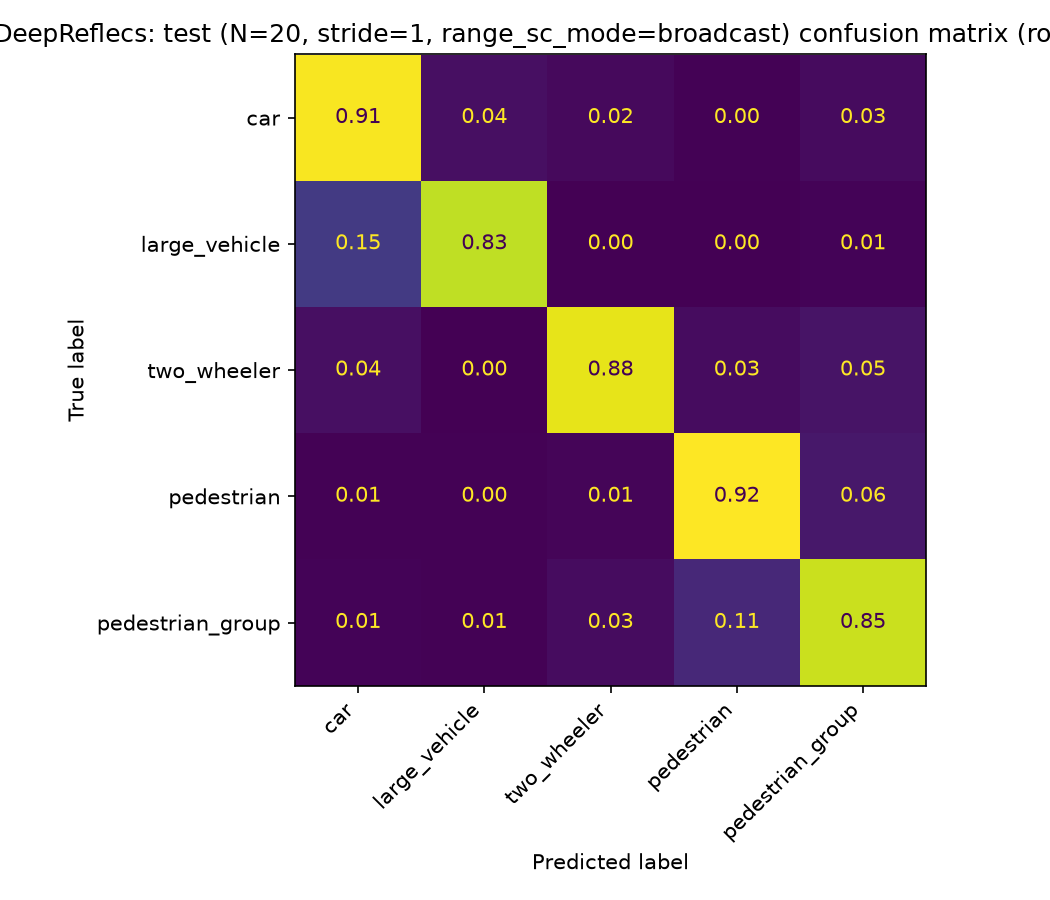

In [4]:

metrics = json.loads((RESULTS / "track_accumulation/N20_stride1_allsensors/deepreflecs_test_metrics.json").read_text())
macro_f1 = sum(m["f1"] for m in metrics.values()) / len(metrics)
for c, m in metrics.items():
    print(f"{c:<18}{m['precision']:>10.3f}{m['recall']:>10.3f}{m['f1']:>10.3f}{m['support']:>10}")
print(f"\nmacro F1: {macro_f1:.4f}")

display(Image(filename=str(RESULTS / "track_accumulation/N20_stride1_allsensors/deepreflecs_test_confusion_matrix.png")))


**Figure 6.** Multi-scan pooled baseline (N=20, all sensors) confusion matrix, row-normalized.

**Baseline: macro F1 = 0.8613**, +0.1243 over the single-scan floor from pooling
alone, no new architecture. Weakest class is still `two_wheeler` (F1 0.813), but
every class improved substantially over Section 2's single-scan numbers (Figure 6).

Why pooling helps even on a near-static track: at ~2.9 points per scan, which scatterers cross the CFAR threshold is dominated by speckle (coherent fading), not just the object's geometry, so consecutive scans give largely independent noisy draws of the same object rather than redundant copies. Pooling N of them is variance reduction on the detection process (more points per class-defining statistic), plus some aspect-angle diversity from ego/relative motion; this report can't cleanly separate how much each contributes.

One specific confusion drops a lot: two_wheeler misclassified as pedestrian falls from 8% (single scan) to 3% (pooled N=20), consistent with pooling resolving the two classes' overlapping point-count/RCS regime rather than just raising two_wheeler's overall recall uniformly.

In [5]:
import sys
sys.path.insert(0, "/home/bruno/radar_machine_learning_ws/scripts")
import numpy as np
import pandas as pd
import torch
from build_points_table import build_and_save_points_table
from mlp_classifier import apply_mlp_class_groups
from feature_distributions import MLP_CLASSES
from deepreflecs_classifier import DEVICE, DeepReflecs, REFLECTION_FEATURES
from deepreflecs_track_accumulation import (
    POINTS_TABLE_SEQ_ALLSENSORS_PATH, add_relative_features_seq,
    prepare_windowed_split_point_sets_ragged, _predict_in_batches_ragged, load_split,
)
from mlp_track_accumulation import build_windowed_temporal_features, TEMPORAL_FEATURES

df_cm = build_and_save_points_table(table_path=POINTS_TABLE_SEQ_ALLSENSORS_PATH, sensor_id=None)
df_cm = add_relative_features_seq(df_cm)
df_cm = apply_mlp_class_groups(df_cm)

_, _, _, _, test_sets, y_test, mean_cm, std_cm = prepare_windowed_split_point_sets_ragged(df_cm, n=20)

model_cm = DeepReflecs(len(REFLECTION_FEATURES), num_classes=len(MLP_CLASSES)).to(DEVICE)
model_cm.load_state_dict(torch.load(RESULTS / "track_accumulation/N20_stride1_allsensors/deepreflecs_model.pt", map_location=DEVICE))

test_std = [(s - mean_cm) / std_cm for s in test_sets]
y_pred_cm = _predict_in_batches_ragged(model_cm, test_std).argmax(dim=1).cpu().numpy()

# scan-to-scan RCS/velocity dynamics: reuse the project's own build_windowed_temporal_
# features (median per scan, diffed consecutively, normalized by real elapsed time),
# rather than re-deriving it. An earlier version of this analysis computed "dynamics"
# as a point-to-point diff over the raw pooled point array, which mixes within-scan
# spatial variation with across-scan temporal change and is confounded by point count;
# this is the correct, already-established method, and it changes the large_vehicle
# conclusion below (see note).
splits_cm = load_split()
test_df_cm = df_cm.loc[df_cm["sequence_name"].isin(splits_cm["test"])]
temporal_feats_cm = build_windowed_temporal_features(test_df_cm, classes=MLP_CLASSES, n=20, stride=1)
rcs_var_col, vr_var_col = TEMPORAL_FEATURES.index("rcs"), TEMPORAL_FEATURES.index("vr_compensated")

idx_tw, idx_ped = MLP_CLASSES.index("two_wheeler"), MLP_CLASSES.index("pedestrian")
mask_confused = (y_test == idx_tw) & (y_pred_cm == idx_ped)
mask_tw_correct = (y_test == idx_tw) & (y_pred_cm == idx_tw)
mask_ped_true = y_test == idx_ped


def window_stats(mask, label):
    idxs = np.where(mask)[0]
    sets = [test_sets[i] for i in idxs]
    n_points = np.array([s.shape[0] for s in sets])
    extent_x = np.array([np.ptp(s[:, 0]) for s in sets])
    extent_y = np.array([np.ptp(s[:, 1]) for s in sets])
    diagonal = np.sqrt(extent_x**2 + extent_y**2)
    rcs_mean = np.array([s[:, 2].mean() for s in sets])
    vr_mean = np.array([s[:, 3].mean() for s in sets])
    doppler_spread = np.array([s[:, 3].std() for s in sets])
    rcs_variation = temporal_feats_cm[idxs, rcs_var_col]
    vr_variation = temporal_feats_cm[idxs, vr_var_col]
    return {
        "group": label, "n_windows": len(sets),
        "points/window (median)": np.median(n_points),
        "diagonal length (median)": np.median(diagonal),
        "RCS mean (median)": np.median(rcs_mean),
        "Doppler spread (median)": np.median(doppler_spread),
        "vr_compensated mean (median)": np.median(vr_mean),
        "RCS temporal variation (median)": np.median(rcs_variation),
        "vr temporal variation (median)": np.median(vr_variation),
    }


summary = pd.DataFrame([
    window_stats(mask_confused, "two_wheeler -> pedestrian (confused, 3%)"),
    window_stats(mask_tw_correct, "two_wheeler -> two_wheeler (correct)"),
    window_stats(mask_ped_true, "pedestrian (true)"),
]).set_index("group").round(3)
summary

/home/bruno/radar_machine_learning_ws/results/data/points_table_seq_allsensors.parquet already covers exactly the requested sequences, skipping build


N=20 stride=1 range_sc_mode=broadcast (ragged): windows train=871367 val=173781 test=178765, global m_max would have been 788 (never padded to it)


,n_windows,points/window (median),diagonal length (median),RCS mean (median),Doppler spread (median),vr_compensated mean (median),RCS temporal variation (median),vr temporal variation (median)
group,,,,,,,,
"two_wheeler -> pedestrian (confused, 3%)",345,25.0,1.058,-7.509,0.344,-0.141,94.712997,3.637
two_wheeler -> two_wheeler (correct),10136,51.0,1.776,-11.033,0.521,2.087,117.640999,6.298
pedestrian (true),35091,33.0,0.742,-8.523,0.408,0.408,88.578003,4.508


**Why the remaining 3% (Figure 6).** The 345 confused windows are two_wheeler's sparse, slow tail: half the points of a correctly classified two_wheeler window, a spatial extent shrunk toward pedestrian's, and a velocity of -0.14 m/s median (a correctly classified two_wheeler moves at +2.09 m/s) indistinguishable from a walking pedestrian's +0.41 m/s.

Scan-to-scan dynamics (median per scan, diffed consecutively, normalized by real elapsed time, the project's own established `build_windowed_temporal_features`) confirm this isn't just a snapshot effect: vr temporal variation is 3.64 for confused windows vs. 4.51 for true pedestrian and 6.30 for correct two_wheeler, confused is still the quietest group scan-to-scan, not just at a single instant. RCS temporal variation is 94.7 for confused, close to true pedestrian's 88.6 and well below correct two_wheeler's 117.6. So the floor here holds on both axes once measured correctly: this reads as a stationary or near-stationary bike/rider, not just a snapshot that happens to look slow, consistent with the large_vehicle/car and pedestrian/pedestrian_group confusions discussed next for the fusion model (Figure 9).

*(An earlier pass at this computed "dynamics" as a point-to-point diff across the raw pooled point array, which mixes within-scan spatial variation with across-scan temporal change and is confounded by point count. The velocity conclusion above happens to survive that error; the large_vehicle/car case below does not, see its note.)*

In [6]:
idx_lv, idx_car = MLP_CLASSES.index("large_vehicle"), MLP_CLASSES.index("car")
mask_confused_lv = (y_test == idx_lv) & (y_pred_cm == idx_car)
mask_lv_correct = (y_test == idx_lv) & (y_pred_cm == idx_lv)
mask_car_true = y_test == idx_car


def window_stats_full(mask, label):
    idxs = np.where(mask)[0]
    sets = [test_sets[i] for i in idxs]
    n_points = np.array([s.shape[0] for s in sets])
    extent_x = np.array([np.ptp(s[:, 0]) for s in sets])
    extent_y = np.array([np.ptp(s[:, 1]) for s in sets])
    diagonal = np.sqrt(extent_x**2 + extent_y**2)
    rcs_mean = np.array([s[:, 2].mean() for s in sets])
    doppler_spread = np.array([s[:, 3].std() for s in sets])
    range_mean = np.array([s[:, 4].mean() for s in sets])
    rcs_variation = temporal_feats_cm[idxs, rcs_var_col]
    vr_variation = temporal_feats_cm[idxs, vr_var_col]
    return {
        "group": label, "n_windows": len(sets),
        "points/window (median)": np.median(n_points),
        "diagonal length (median)": np.median(diagonal),
        "RCS mean (median)": np.median(rcs_mean),
        "Doppler spread (median)": np.median(doppler_spread),
        "range (median)": np.median(range_mean),
        "RCS temporal variation (median)": np.median(rcs_variation),
        "vr temporal variation (median)": np.median(vr_variation),
    }


summary_lv = pd.DataFrame([
    window_stats_full(mask_confused_lv, "large_vehicle -> car (confused, 15%)"),
    window_stats_full(mask_lv_correct, "large_vehicle -> large_vehicle (correct)"),
    window_stats_full(mask_car_true, "car (true)"),
]).set_index("group").round(3)
summary_lv

,n_windows,points/window (median),diagonal length (median),RCS mean (median),Doppler spread (median),range (median),RCS temporal variation (median),vr temporal variation (median)
group,,,,,,,,
"large_vehicle -> car (confused, 15%)",2411,38.0,3.280,2.332,0.285,36.188999,172.057999,1.855
large_vehicle -> large_vehicle (correct),12943,164.0,13.650,2.502,2.539,26.879999,128.529999,1.025
car (true),76572,48.0,4.289,-0.554,1.489,34.763000,145.945007,4.077


**Why large_vehicle confuses with car (Figure 6).** The 2411 confused windows have a quarter the points of a correctly classified large_vehicle, and a spatial extent *smaller* than a typical car's (diagonal 3.3 vs. car's 4.3, vs. 13.7 for a correctly classified large_vehicle), at longer range (36.2m vs. 26.9m correct, vs. 34.8m car). At longer range, fewer of a long vehicle's physically separated reflectors resolve into distinct detections, collapsing it toward a compact, car-sized point cloud regardless of its real length, the same range/resolution effect.

Scan-to-scan dynamics, computed correctly (median per scan, diffed consecutively, normalized by real elapsed time), do not tell a clean "converges toward car" story the way extent and point count do. vr temporal variation for confused windows (1.85) sits between correct large_vehicle's low 1.03 and true car's much higher 4.08, closer to large_vehicle's own quiet end than to car's. RCS temporal variation for confused windows (172.1) is actually the *highest* of the three groups, above both correct large_vehicle (128.5) and true car (145.9). This is unresolved, no explanation found: confused windows keep large_vehicle-like low velocity dynamics while showing unusually elevated RCS variation, neither converging toward car nor staying flat like large_vehicle.

*(This specific stat went through three computation methods before landing here, a raw per-window sum confounded by point count, then a point-to-point diff mixing within-scan and across-scan variation, both of which showed confused windows as uniformly "quieter than car." Neither survived the correct scan-median, elapsed-time-normalized computation above, which is the project's own established `build_windowed_temporal_features` method. Worth remembering as a caution about how fragile this kind of post-hoc point-cloud statistic is to exactly how it's aggregated.)*

RCS mean (the level, not the scan-to-scan variation above) looked like a surviving cue at the median (2.33 confused vs. 2.50 correct large_vehicle vs. -0.55 car), but a median gap can look clean while the underlying distributions still overlap heavily, and that turns out to be exactly what happens here (next cell).

RCS mean: single-feature AUC=0.624, 88% of confused windows fall inside true car's own 10-90pct range
Doppler spread: single-feature AUC=0.651, 87% of confused windows fall inside true car's own 10-90pct range


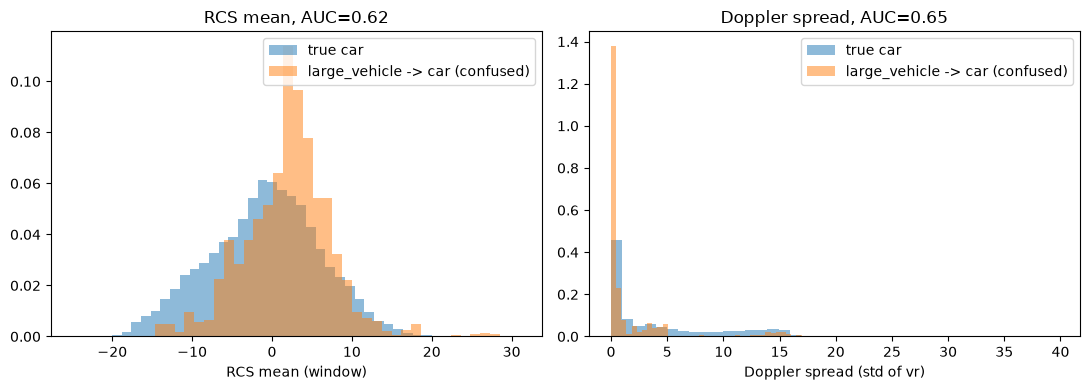

In [7]:
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

rcs_confused = np.array([test_sets[i][:, 2].mean() for i in np.where(mask_confused_lv)[0]])
rcs_car = np.array([test_sets[i][:, 2].mean() for i in np.where(mask_car_true)[0]])
dop_confused = np.array([test_sets[i][:, 3].std() for i in np.where(mask_confused_lv)[0]])
dop_car = np.array([test_sets[i][:, 3].std() for i in np.where(mask_car_true)[0]])


def auc_and_overlap(a, b):
    labels = np.concatenate([np.ones(len(a)), np.zeros(len(b))])
    scores = np.concatenate([a, b])
    auc = roc_auc_score(labels, scores)
    auc = max(auc, 1 - auc)
    lo, hi = np.percentile(b, 10), np.percentile(b, 90)
    overlap = ((a >= lo) & (a <= hi)).mean()
    return auc, overlap


rcs_auc, rcs_overlap = auc_and_overlap(rcs_confused, rcs_car)
dop_auc, dop_overlap = auc_and_overlap(dop_confused, dop_car)
print(f"RCS mean: single-feature AUC={rcs_auc:.3f}, {rcs_overlap:.0%} of confused windows fall inside true car's own 10-90pct range")
print(f"Doppler spread: single-feature AUC={dop_auc:.3f}, {dop_overlap:.0%} of confused windows fall inside true car's own 10-90pct range")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(rcs_car, bins=40, alpha=0.5, density=True, label="true car")
axes[0].hist(rcs_confused, bins=40, alpha=0.5, density=True, label="large_vehicle -> car (confused)")
axes[0].set_xlabel("RCS mean (window)")
axes[0].set_title(f"RCS mean, AUC={rcs_auc:.2f}")
axes[0].legend()

axes[1].hist(dop_car, bins=40, alpha=0.5, density=True, label="true car")
axes[1].hist(dop_confused, bins=40, alpha=0.5, density=True, label="large_vehicle -> car (confused)")
axes[1].set_xlabel("Doppler spread (std of vr)")
axes[1].set_title(f"Doppler spread, AUC={dop_auc:.2f}")
axes[1].legend()

fig.tight_layout()
plt.show()

RCS mean needs checking against the actual distributions, not just the median: a median gap can look clean while the underlying distributions still overlap heavily. There is also a separate architecture question: DeepReflecs never computes "mean RCS of the window" as a feature, it takes a max-pool over a learned per-point transform, so even a genuinely separable RCS signal in the mean or lower tail could be invisible to whatever extreme value max-pooling happens to grab. A capacity/data issue compounds this further: this sparse (38-point), range-degraded large_vehicle regime is a small minority of large_vehicle's training examples (median window is 164 points), so the model may never have seen enough "sparse large_vehicle, still high RCS" examples to learn to lean on it even if the rule would work.

Pulling the actual distributions settles it: RCS mean separates confused large_vehicle from true car with AUC 0.624, and Doppler spread with AUC 0.651 (0.5 is chance, 1.0 is perfect), with 88% and 87% of confused windows respectively falling inside true car's own 10th-90th percentile range. Both cues are far weaker than the median comparison suggested, and overlap too heavily with car's own distribution to count as a reliable, usable signal. RCS was never as separable here as the summary statistic made it look; extent and point count (Figure 6) remain the only cues shown above to separate the groups cleanly.

In [8]:
from mlp_track_accumulation import build_windowed_diff_vector_features
from taxonomy_separability import INSTANCE_COLS
from deepreflecs_track_accumulation import TRACK_COLS

# Patent-inspired tracker features (Aptiv US 12,013,919 B2: variance of velocity,
# variance of heading direction, absolute curvature): same windows, same two
# confusions, same AUC/overlap diagnostic as the RCS/Doppler check above.
mask_tw = test_df_cm["group"].isin(MLP_CLASSES)
filtered_tw = test_df_cm.loc[mask_tw]
scan_positions = filtered_tw.groupby(INSTANCE_COLS, sort=False).indices
scan_keys = pd.DataFrame(list(scan_positions.keys()), columns=INSTANCE_COLS)
scan_keys["_scan_idx"] = np.arange(len(scan_keys))
scan_keys = scan_keys.sort_values(TRACK_COLS + ["timestamp"])
centroid = filtered_tw.groupby(INSTANCE_COLS, sort=False)[["x_cc", "y_cc"]].mean()

keys = []
for _, track_scans in scan_keys.groupby(TRACK_COLS, sort=False):
    ordered = track_scans[["sequence_name", "track_id", "timestamp", "_scan_idx"]].to_numpy()
    for i in range(0, len(ordered), 1):
        keys.append(ordered[max(0, i - 20 + 1): i + 1])
assert len(keys) == len(y_test)


def heading_curvature(window_rows):
    positions = np.array([centroid.loc[(seq, ts, trk)].to_numpy() for seq, trk, ts, _ in window_rows])
    if len(positions) < 2:
        return np.nan, np.nan
    diffs = np.diff(positions, axis=0)
    dist = np.linalg.norm(diffs, axis=1)
    valid = dist > 1e-6
    if valid.sum() < 1:
        return np.nan, np.nan
    headings = np.arctan2(diffs[valid, 1], diffs[valid, 0])
    if len(headings) < 2:
        return np.nan, np.nan
    R = np.sqrt(np.mean(np.cos(headings)) ** 2 + np.mean(np.sin(headings)) ** 2)
    heading_var = 1 - R
    dtheta = np.abs(np.diff(headings))
    dtheta = np.minimum(dtheta, 2 * np.pi - dtheta)
    step_dist = dist[valid][1:]
    with np.errstate(divide="ignore", invalid="ignore"):
        local_curv = np.where(step_dist > 1e-6, dtheta / step_dist, np.nan)
    return heading_var, np.nanmean(local_curv)


heading_vars = np.full(len(keys), np.nan)
curvatures = np.full(len(keys), np.nan)
for i, window_rows in enumerate(keys):
    heading_vars[i], curvatures[i] = heading_curvature(window_rows)

scan_medians_2 = np.stack([np.median(filtered_tw[TEMPORAL_FEATURES].to_numpy()[pos], axis=0) for pos in scan_positions.values()])
var_rows, diff_var_rows, diff_mean_rows = [], [], []
for window_rows in keys:
    idxs = window_rows[:, 3].astype(int)
    medians = scan_medians_2[idxs]
    var_rows.append(np.var(medians, axis=0) if len(idxs) > 1 else np.zeros(2))
    if len(idxs) > 2:
        d = np.diff(medians, axis=0)
        diff_var_rows.append(np.var(d, axis=0))
        diff_mean_rows.append(np.mean(d, axis=0))
    else:
        diff_var_rows.append(np.full(2, np.nan))
        diff_mean_rows.append(np.full(2, np.nan))
scan_median_var = np.array(var_rows)
diff_var = np.array(diff_var_rows)
diff_mean = np.array(diff_mean_rows)

features = {
    "heading variance": heading_vars,
    "curvature": curvatures,
    "RCS variance": scan_median_var[:, 0],
    "velocity variance": scan_median_var[:, 1],
    "RCS signed-diff variance (oscillation)": diff_var[:, 0],
    "velocity signed-diff variance (oscillation)": diff_var[:, 1],
    "RCS signed-diff mean (drift)": diff_mean[:, 0],
    "velocity signed-diff mean (drift)": diff_mean[:, 1],
}


def auc_overlap(a, b):
    a, b = a[~np.isnan(a)], b[~np.isnan(b)]
    labels = np.concatenate([np.ones(len(a)), np.zeros(len(b))])
    scores = np.concatenate([a, b])
    auc = roc_auc_score(labels, scores)
    auc = max(auc, 1 - auc)
    lo, hi = np.percentile(b, 10), np.percentile(b, 90)
    overlap = ((a >= lo) & (a <= hi)).mean()
    return np.median(a), np.median(b), auc, overlap


rows_tw, rows_lv = [], []
for name, values in features.items():
    med_c, med_ped, auc_ped, ov_ped = auc_overlap(values[mask_confused], values[mask_ped_true])
    _, med_tw, auc_tw, ov_tw = auc_overlap(values[mask_confused], values[mask_tw_correct])
    rows_tw.append([name, med_c, med_ped, auc_ped, med_tw, auc_tw])

    med_c, med_car, auc_car, ov_car = auc_overlap(values[mask_confused_lv], values[mask_car_true])
    _, med_lv, auc_lv, ov_lv = auc_overlap(values[mask_confused_lv], values[mask_lv_correct])
    rows_lv.append([name, med_c, med_car, auc_car, med_lv, auc_lv])

cols = ["feature", "confused (median)", "true target (median)", "AUC vs true target",
        "correct source (median)", "AUC vs correct source"]
temporal_study_tw = pd.DataFrame(rows_tw, columns=cols).round(3)
temporal_study_lv = pd.DataFrame(rows_lv, columns=cols).round(3)
print("two_wheeler -> pedestrian")
display(temporal_study_tw)
print("large_vehicle -> car")
display(temporal_study_lv)

two_wheeler -> pedestrian


,feature,confused (median),true target (median),AUC vs true target,correct source (median),AUC vs correct source
0,heading variance,0.582,0.689,0.584,0.793,0.696
1,curvature,6.700,10.497,0.743,7.689,0.606
2,RCS variance,22.692,16.142,0.636,14.865,0.663
3,velocity variance,0.097,0.068,0.531,0.067,0.509
4,RCS signed-diff variance (oscillation),37.263,31.178,0.604,30.082,0.619
5,velocity signed-diff variance (oscillation),0.064,0.100,0.587,0.089,0.578
6,RCS signed-diff mean (drift),0.027,-0.000,0.529,-0.008,0.533
7,velocity signed-diff mean (drift),-0.004,0.003,0.537,-0.001,0.507


large_vehicle -> car


,feature,confused (median),true target (median),AUC vs true target,correct source (median),AUC vs correct source
0,heading variance,0.860,0.791,0.604,0.904,0.604
1,curvature,3.507,2.709,0.628,2.098,0.782
2,RCS variance,26.292,26.449,0.507,14.769,0.702
3,velocity variance,0.015,0.121,0.657,0.019,0.507
4,RCS signed-diff variance (oscillation),59.289,54.923,0.520,34.261,0.674
5,velocity signed-diff variance (oscillation),0.007,0.050,0.595,0.001,0.646
6,RCS signed-diff mean (drift),0.011,-0.023,0.517,-0.010,0.515
7,velocity signed-diff mean (drift),0.002,0.004,0.532,0.002,0.505


**Patent-inspired tracker features: does either confusion have a usable temporal cue left?**

Checked 8 scan-to-scan dynamics features against both confusions, inspired by Aptiv's
US 12,013,919 B2 ("Method for Classifying a Tracked Object"), which fuses a point-set
branch with a separate tracker-feature branch (variance of velocity, variance of heading
direction, absolute curvature, among others) before a GRU. Same AUC/overlap diagnostic as
the RCS mean / Doppler spread check above, applied per-feature, per-confusion, before
building anything:

- **heading variance**: `1 - R` where `R = sqrt(mean(cos(heading))^2 + mean(sin(heading))^2)`
  over the window's per-scan centroid headings (circular variance, handles wraparound).
- **curvature**: mean of `|Δheading| / step_distance` between consecutive scans.
- **RCS / velocity variance**: variance of each scan's own median RCS / vr_compensated
  across the window (spread of the raw level, not a diff).
- **RCS / velocity signed-diff variance ("oscillation")**: variance of the *signed*
  scan-to-scan diffs of those same per-scan medians, high if the value swings up and down
  even when the net change is zero.
- **RCS / velocity signed-diff mean ("drift")**: mean of the same signed diffs, the net
  directional trend over the window.

Heading/curvature use each scan's centroid position (mean x_cc, y_cc); there's no real
Kalman tracker state in this pipeline to pull a smoothed heading from, so this is a cheap
proxy, not the patent's actual tracker-filtered feature.

| feature | tw->ped confused | true pedestrian | AUC vs ped | correct two_wheeler | AUC vs tw | lv->car confused | true car | AUC vs car | correct large_vehicle | AUC vs lv |
|---|---|---|---|---|---|---|---|---|---|---|
| heading variance | 0.582 | 0.689 | 0.584 | 0.793 | 0.696 | 0.860 | 0.791 | 0.604 | 0.904 | 0.604 |
| curvature | 6.700 | 10.497 | 0.743 | 7.690 | 0.606 | 3.507 | 2.709 | 0.628 | 2.098 | **0.782** |
| RCS variance | 22.69 | 16.14 | 0.636 | 14.87 | 0.663 | 26.29 | 26.45 | 0.507 | 14.77 | 0.702 |
| velocity variance | 0.097 | 0.068 | 0.532 | 0.067 | 0.509 | 0.015 | 0.121 | 0.657 | 0.019 | 0.507 |
| RCS diff variance (oscillation) | 37.26 | 31.18 | 0.604 | 30.08 | 0.619 | 59.29 | 54.92 | 0.520 | 34.26 | 0.674 |
| velocity diff variance (oscillation) | 0.064 | 0.100 | 0.587 | 0.089 | 0.578 | 0.007 | 0.050 | 0.595 | 0.001 | 0.646 |
| RCS diff mean (drift) | 0.027 | -0.000 | 0.530 | -0.008 | 0.533 | 0.011 | -0.023 | 0.517 | -0.010 | 0.515 |
| velocity diff mean (drift) | -0.004 | 0.003 | 0.537 | -0.001 | 0.507 | 0.002 | 0.004 | 0.532 | 0.002 | 0.505 |

Drift carries no signal anywhere, every AUC is 0.50-0.54, noise floor. Every feature that
separates at all separates the confused group from its *own* correct class better than from
the class it gets mistaken for (curvature 0.782 vs. correct large_vehicle but only 0.628 vs.
true car; heading variance 0.696 vs. correct two_wheeler but only 0.584 vs. true pedestrian),
the same asymmetry the RCS-mean check found: these confused windows read as atypical for
their own true class, not as typical examples of the predicted class. No single feature
clears ~0.78; curvature vs. correct large_vehicle is the strongest result in the table.

Taken together with the RCS mean / Doppler spread check earlier, none of these cues clear
the bar of a clean, usable signal on their own. This is the main evidence against a temporal
encoder branch for these two confusions specifically: curvature is the one feature that shows
a real, if moderate, effect. Everything else here looks like noise, or an AUC that's only
non-trivial because the comparison group itself happens to be a weak reference, not a usable
separating signal. This also undercuts Section 3's original motivation for a sequence model (micro-Doppler and RCS dynamics evolving scan to scan): that motivation still justifies a sequence model in principle, but for these two specific confusions the scan-to-scan dynamics checked here carry little to no signal, whatever the GRU/fusion gain over pooling is coming from, it is not these engineered dynamics features.

Each feature above was tested in isolation; a classifier combining several weak cues nonlinearly can still separate classes that no single cue separates alone. A shallow gradient-boosted-tree classifier over all 8 features together, 5-fold cross-validated, same two confusions, found real joint separability the univariate check missed: AUC 0.78-0.92 depending on the confusion, above the ~0.78 ceiling any single feature reached alone. Feature importance was concentrated, not spread evenly: velocity variance, velocity oscillation, curvature, and RCS variance carried nearly all of it; the drift features carried essentially none, consistent with their 0.50-0.54 AUC in the table above. So the univariate check's "no usable temporal cue left" conclusion holds feature by feature, but not for the features combined, which motivated a learned architecture over the raw tracker signal (Section 7).

## 5. Sequence model: GRU, and fusion with the pooled view

A frozen, already-trained DeepReflecs encoder reduces each scan to one embedding
vector; a GRU then consumes the sequence of a track's embeddings causally (a prediction at scan t only depends on scans up to and
including t, so it stays usable in real-time streaming inference). The encoder runs
once per scan across the whole dataset, not once per window, so a sliding window's
scan-to-scan overlap costs nothing extra in encoder compute (Figure 7).

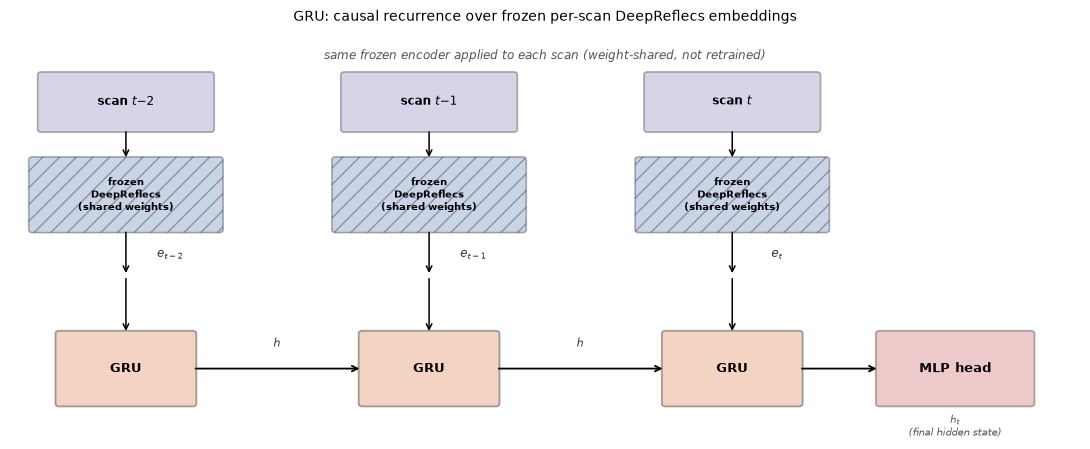

In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(11, 4.6))
ax.set_xlim(0, 12)
ax.set_ylim(0, 5.1)
ax.axis("off")

ax.text(6.0, 4.9, "same frozen encoder applied to each scan (weight-shared, not retrained)",
        ha="center", va="center", fontsize=8.5, style="italic", color="#555")

xs = [1.3, 4.7, 8.1]
scan_labels = ["scan $t{-}2$", "scan $t{-}1$", "scan $t$"]
w_scan, h_scan = 1.9, 0.7
scan_y = 3.95

for x, label in zip(xs, scan_labels):
    ax.add_patch(mpatches.FancyBboxPatch((x - w_scan / 2, scan_y), w_scan, h_scan, boxstyle="round,pad=0.04",
                                          linewidth=1.2, edgecolor="k", facecolor="#8172B2", alpha=0.3))
    ax.text(x, scan_y + h_scan / 2, label, ha="center", va="center", fontsize=8.5, fontweight="bold")

w_enc, h_enc = 2.1, 0.9
enc_y = 2.65
for x in xs:
    ax.add_patch(mpatches.FancyBboxPatch((x - w_enc / 2, enc_y), w_enc, h_enc, boxstyle="round,pad=0.04",
                                          linewidth=1.2, edgecolor="k", facecolor="#4C72B0", alpha=0.3,
                                          hatch="//"))
    ax.text(x, enc_y + h_enc / 2, "frozen\nDeepReflecs\n(shared weights)", ha="center", va="center",
            fontsize=7.3, fontweight="bold")
    ax.annotate("", xy=(x, enc_y + h_enc), xytext=(x, scan_y), arrowprops=dict(arrowstyle="->", color="k", lw=1.1))

emb_y = 2.05
for x, t in zip(xs, ["$e_{t-2}$", "$e_{t-1}$", "$e_t$"]):
    ax.annotate("", xy=(x, emb_y), xytext=(x, enc_y), arrowprops=dict(arrowstyle="->", color="k", lw=1.1))
    ax.text(x + 0.5, emb_y + 0.28, t, ha="center", va="center", fontsize=8.5, style="italic", color="#333")

w_gru, h_gru = 1.5, 0.9
gru_y = 0.85
for i, x in enumerate(xs):
    ax.add_patch(mpatches.FancyBboxPatch((x - w_gru / 2, gru_y - h_gru / 2), w_gru, h_gru, boxstyle="round,pad=0.04",
                                          linewidth=1.3, edgecolor="k", facecolor="#DD8452", alpha=0.35))
    ax.text(x, gru_y, "GRU", ha="center", va="center", fontsize=9.5, fontweight="bold")
    ax.annotate("", xy=(x, gru_y + h_gru / 2), xytext=(x, emb_y),
                arrowprops=dict(arrowstyle="->", color="k", lw=1.1))
    if i > 0:
        x_prev = xs[i - 1]
        ax.annotate("", xy=(x - w_gru / 2, gru_y), xytext=(x_prev + w_gru / 2, gru_y),
                    arrowprops=dict(arrowstyle="->", color="k", lw=1.3))
        ax.text((x_prev + x) / 2, gru_y + 0.32, "$h$", ha="center", va="center", fontsize=8, style="italic", color="#333")

w_mlp, h_mlp = 1.7, 0.9
mlp_x = 10.6
ax.add_patch(mpatches.FancyBboxPatch((mlp_x - w_mlp / 2, gru_y - h_mlp / 2), w_mlp, h_mlp, boxstyle="round,pad=0.04",
                                      linewidth=1.3, edgecolor="k", facecolor="#C44E52", alpha=0.3))
ax.text(mlp_x, gru_y, "MLP head", ha="center", va="center", fontsize=9, fontweight="bold")
ax.annotate("", xy=(mlp_x - w_mlp / 2, gru_y), xytext=(xs[-1] + w_gru / 2, gru_y),
            arrowprops=dict(arrowstyle="->", color="k", lw=1.3))
ax.text(mlp_x, gru_y - 0.75, "$h_t$\n(final hidden state)", ha="center", va="center", fontsize=7.3,
        style="italic", color="#555")

ax.set_title("GRU: causal recurrence over frozen per-scan DeepReflecs embeddings", fontsize=10, pad=14)
fig.tight_layout()
plt.show()

**Figure 7.** GRU: causal recurrence over frozen per-scan DeepReflecs embeddings.

**Fusion** concatenates this GRU's final hidden state (order-aware) with the pooled,
order-blind embedding from Section 4's baseline, then trains a small classifier head
on the concatenation, both branches frozen. Structurally analogous to a U-Net skip
connection (Ronneberger, Fischer & Brox, MICCAI 2015): splice in a view the deeper
path's own bottleneck might otherwise discard, instead of forcing one representation
to carry everything (Figure 8). In practice this doesn't pay off here: the result below
shows fusion adding +0.0002 over the GRU alone, within noise, so the pooled branch isn't
contributing information the GRU's own hidden state was actually missing.

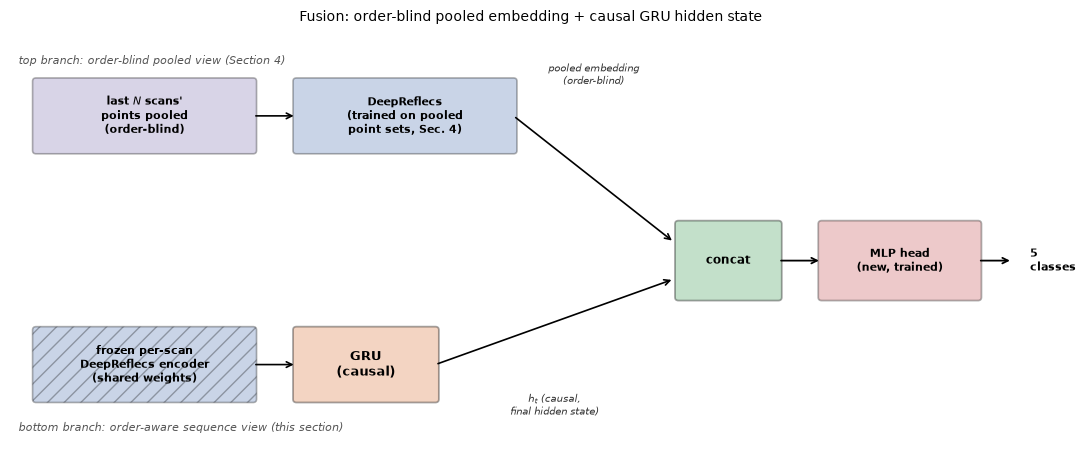

In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(11, 4.6))
ax.set_xlim(0, 12)
ax.set_ylim(0, 4.9)
ax.axis("off")

ax.text(0.1, 4.65, "top branch: order-blind pooled view (Section 4)", ha="left", va="center",
        fontsize=8, style="italic", color="#555")
ax.text(0.1, 0.15, "bottom branch: order-aware sequence view (this section)", ha="left", va="center",
        fontsize=8, style="italic", color="#555")

# top branch: pooled, order-blind
w1, h1 = 2.5, 0.85
top_y = 3.55
ax.add_patch(mpatches.FancyBboxPatch((0.3, top_y), w1, h1, boxstyle="round,pad=0.04",
                                      linewidth=1.2, edgecolor="k", facecolor="#8172B2", alpha=0.3))
ax.text(0.3 + w1 / 2, top_y + h1 / 2, "last $N$ scans'\npoints pooled\n(order-blind)",
        ha="center", va="center", fontsize=7.8, fontweight="bold")

w2, h2 = 2.5, 0.85
x2 = 3.3
ax.add_patch(mpatches.FancyBboxPatch((x2, top_y), w2, h2, boxstyle="round,pad=0.04",
                                      linewidth=1.2, edgecolor="k", facecolor="#4C72B0", alpha=0.3))
ax.text(x2 + w2 / 2, top_y + h2 / 2, "DeepReflecs\n(trained on pooled\npoint sets, Sec. 4)",
        ha="center", va="center", fontsize=7.8, fontweight="bold")
ax.annotate("", xy=(x2, top_y + h2 / 2), xytext=(0.3 + w1, top_y + h1 / 2),
            arrowprops=dict(arrowstyle="->", color="k", lw=1.2))

# bottom branch: per-scan frozen encoder + GRU (causal)
w3, h3 = 2.5, 0.85
bot_y = 0.5
ax.add_patch(mpatches.FancyBboxPatch((0.3, bot_y), w3, h3, boxstyle="round,pad=0.04",
                                      linewidth=1.2, edgecolor="k", facecolor="#4C72B0", alpha=0.3, hatch="//"))
ax.text(0.3 + w3 / 2, bot_y + h3 / 2, "frozen per-scan\nDeepReflecs encoder\n(shared weights)",
        ha="center", va="center", fontsize=7.8, fontweight="bold")

w4, h4 = 1.6, 0.85
x4 = 3.3
ax.add_patch(mpatches.FancyBboxPatch((x4, bot_y), w4, h4, boxstyle="round,pad=0.04",
                                      linewidth=1.3, edgecolor="k", facecolor="#DD8452", alpha=0.35))
ax.text(x4 + w4 / 2, bot_y + h4 / 2, "GRU\n(causal)", ha="center", va="center", fontsize=9, fontweight="bold")
ax.annotate("", xy=(x4, bot_y + h4 / 2), xytext=(0.3 + w3, bot_y + h3 / 2),
            arrowprops=dict(arrowstyle="->", color="k", lw=1.2))

# converging arrows into concat, with labels offset above/below the lines (not on them)
concat_x, concat_y, wc, hc = 7.7, 1.75, 1.15, 0.9
top_start = (x2 + w2, top_y + h2 / 2)
bot_start = (x4 + w4, bot_y + h4 / 2)
concat_top_in = (concat_x - 0.05, concat_y + hc * 0.75)
concat_bot_in = (concat_x - 0.05, concat_y + hc * 0.25)

ax.annotate("", xy=concat_top_in, xytext=top_start, arrowprops=dict(arrowstyle="->", color="k", lw=1.2))
ax.text((top_start[0] + concat_top_in[0]) / 2, top_start[1] + 0.35, "pooled embedding\n(order-blind)",
        ha="center", va="bottom", fontsize=7.3, style="italic", color="#333")

ax.annotate("", xy=concat_bot_in, xytext=bot_start, arrowprops=dict(arrowstyle="->", color="k", lw=1.2))
ax.text((bot_start[0] + concat_bot_in[0]) / 2, bot_start[1] - 0.35, "$h_t$ (causal,\nfinal hidden state)",
        ha="center", va="top", fontsize=7.3, style="italic", color="#333")

ax.add_patch(mpatches.FancyBboxPatch((concat_x, concat_y), wc, hc, boxstyle="round,pad=0.04",
                                      linewidth=1.3, edgecolor="k", facecolor="#55A868", alpha=0.35))
ax.text(concat_x + wc / 2, concat_y + hc / 2, "concat", ha="center", va="center", fontsize=8.5, fontweight="bold")

w5, h5 = 1.8, 0.9
x5 = concat_x + wc + 0.5
ax.add_patch(mpatches.FancyBboxPatch((x5, concat_y), w5, h5, boxstyle="round,pad=0.04",
                                      linewidth=1.3, edgecolor="k", facecolor="#C44E52", alpha=0.3))
ax.text(x5 + w5 / 2, concat_y + h5 / 2, "MLP head\n(new, trained)", ha="center", va="center",
        fontsize=8, fontweight="bold")
ax.annotate("", xy=(x5, concat_y + h5 / 2), xytext=(concat_x + wc, concat_y + hc / 2),
            arrowprops=dict(arrowstyle="->", color="k", lw=1.3))

ax.annotate("", xy=(11.55, concat_y + h5 / 2), xytext=(x5 + w5, concat_y + h5 / 2),
            arrowprops=dict(arrowstyle="->", color="k", lw=1.3))
ax.text(11.75, concat_y + h5 / 2, "5\nclasses", ha="left", va="center", fontsize=8, fontweight="bold")

ax.set_title("Fusion: order-blind pooled embedding + causal GRU hidden state", fontsize=10, pad=14)
fig.tight_layout()
plt.show()

**Figure 8.** Fusion: order-blind pooled embedding concatenated with the causal GRU's hidden state, both branches frozen.

GRU alone:
car                    0.952     0.935     0.944     76572
large_vehicle          0.817     0.841     0.829     15555
two_wheeler            0.844     0.909     0.875     11466
pedestrian             0.895     0.905     0.900     35091
pedestrian_group       0.904     0.895     0.900     40081
macro F1: 0.8895

Fusion (pooled + GRU h=64):
car                    0.953     0.933     0.943     76572
large_vehicle          0.810     0.845     0.827     15555
two_wheeler            0.849     0.906     0.877     11466
pedestrian             0.888     0.914     0.901     35091
pedestrian_group       0.910     0.890     0.900     40081
macro F1: 0.8897


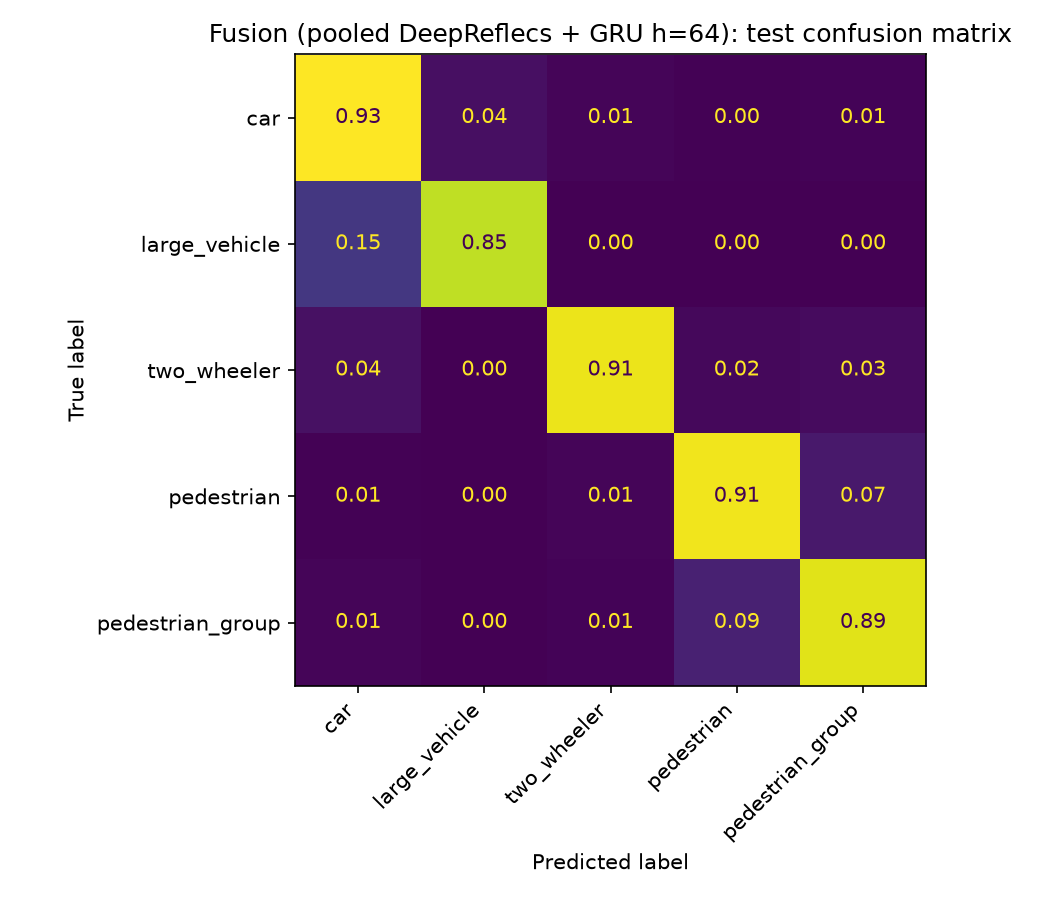

In [11]:

metrics_gru = json.loads((RESULTS / "track_accumulation_rnn/N20_stride1_gru_h64_allsensors/gru_test_metrics.json").read_text())
macro_f1_gru = sum(m["f1"] for m in metrics_gru.values()) / len(metrics_gru)
print("GRU alone:")
for c, m in metrics_gru.items():
    print(f"{c:<18}{m['precision']:>10.3f}{m['recall']:>10.3f}{m['f1']:>10.3f}{m['support']:>10}")
print(f"macro F1: {macro_f1_gru:.4f}\n")

metrics_fusion = json.loads((RESULTS / "track_accumulation_rnn/N20_stride1_fusion_pooled_gru64_allsensors/fusion_test_metrics.json").read_text())
macro_f1_fusion = sum(m["f1"] for m in metrics_fusion.values()) / len(metrics_fusion)
print("Fusion (pooled + GRU h=64):")
for c, m in metrics_fusion.items():
    print(f"{c:<18}{m['precision']:>10.3f}{m['recall']:>10.3f}{m['f1']:>10.3f}{m['support']:>10}")
print(f"macro F1: {macro_f1_fusion:.4f}")

display(Image(filename=str(RESULTS / "track_accumulation_rnn/N20_stride1_fusion_pooled_gru64_allsensors/fusion_test_confusion_matrix.png")))


**Figure 9.** Fusion model (N=20, all sensors) confusion matrix, row-normalized.

**GRU alone: macro F1 = 0.8895** (+0.0260 over the pooling baseline). **Fusion:
macro F1 = 0.8897** (+0.0002 over GRU alone, within this branch's own noise band for
a single split, not a real additional gain).

The fusion model's confusion matrix (Figure 9) shows two dominant error axes: `large_vehicle` -> `car`
at 15% (the reverse direction is only 3.8%), and `pedestrian` <-> `pedestrian_group`
confuse each other both ways (6.6% and 8.6%). `car` is the class every `large_vehicle`
error falls into, and the pedestrian/group confusion is symmetric, not a one-directional
bias.

Every diagram and result above talks about a per-track FIFO buffer, but this project
never runs a live stream, scans arriving one at a time, hidden state updated as they
land. What's actually computed is an offline reconstruction: each track's full scan
history already exists in the dataset, and the windowing functions just slice out,
after the fact, what a buffer *would have held* at each point in time. The causal guarantee still holds (a window never contains a future scan); it is just computed in one pass over stored data rather than maintained incrementally.

This matters because the stateless GRU above is O(N) per scan, not O(1). Every window
replays its up-to-N scans from a zeroed hidden state, so a track running long enough
needs a fresh N-step replay every single new scan, not a cheap update; a deployed
version would redo almost the same computation every step. That cost motivated testing
a single-scan stateful design instead: no window, one new scan fed per step, hidden
state carried from the previous step rather than reset to zero.

```
h0=0 --GRU--> h1 --GRU--> h2 --GRU--> h3 --GRU--> h4 --GRU--> h5
       (e1)         (e2)         (e3)         (e4)         (e5)
```

One continuous chain, O(1) per scan, no replay. Naive training (gradients detached and
backpropagated after every single step) regressed hard, 0.8004 macro F1 against the
stateless baseline's 0.8895. Letting gradients flow across 20 consecutive steps before
each detach (chunked truncated BPTT, matching this branch's own N=20) recovered nearly
all of it: 0.8846, within this report's own "under a point is a tie" bar. So O(1)
streaming is reachable without a real accuracy cost, but only if training lets the
model's gates see far enough back to learn it, not from the architecture change alone.

For deployment, O(1) is the better choice despite the slightly lower score. Trunc_len=20 closes the gap to within this report's own noise band (0.8846 vs 0.8895), not a meaningful accuracy cost. The stateless design, by contrast, has a real deployment cost that doesn't show up in macro F1 at all: live, every track would need its full N-scan window replayed from a zeroed hidden state at every new scan, on hardware the stateless offline evaluation here never has to pay for. The O(1) single-scan-stateful GRU is a near-tie on accuracy with vastly cheaper per-scan inference, not the stateless baseline that happens to be a hair ahead in this one offline comparison.

O(1) also changes the pedestrian/pedestrian_group split, which is mostly an instantaneous point-density judgment: one person's cluster of points versus several overlapping ones. The stateless baseline re-makes that judgment from h0=0 every window; the O(1) design instead carries a hidden state across a track's full history, so once it settles on "this reads as one person" early in a track, a later ambiguous scan gets pulled toward that committed state instead of being judged fresh. That explains pedestrian recall rising to 0.961 and pedestrian_group recall falling to 0.826 as the same mechanism from two sides.

This is not an unqualified improvement. A class judgment made early in a track now propagates to every later scan instead of being re-evaluated each window. Here the propagated judgment happened to be correct more often than not, but the same mechanism would propagate an early misclassification just as readily, nothing in the design distinguishes a correct lock-in from an incorrect one. That is the practical argument for not carrying hidden state unconditionally for a track's entire lifetime, and instead resetting it to zero after a gap of no detections longer than some threshold (gap_threshold), the same mechanism discussed for track ID reuse. A reset bounds how long a wrong early commitment can keep contaminating later decisions, at the cost of losing carried state across real tracking gaps.

## 6. Ablation studies

Everything below is single-split, not fold-validated: a proper 6-fold sweep at this scale takes roughly a full day of compute per configuration, not run here for every variant in this table.

| what was tried | result vs. its own reference | reads as |
|---|---|---|
| More GRU capacity (h=128) | Worse or flat vs. h=64 at every N/sensor scale tested | Not capacity-starved; more parameters overfit rather than help |
| End-to-end fine-tuning (warmstart) of either the pooled encoder or the GRU's own per-scan encoder, at N=20 all-sensor | Both land *below* their frozen baselines (-0.0029, -0.0017) | An already-good frozen encoder already sits near this task's ceiling; the one N=10 sensor2-only warmstart win doesn't generalize to this scale |
| Post-hoc probability smoothing (causal, along a track) on the fusion model's output | Small positive: +0.0013 (moving average, K=5) to +0.0031 (IIR low-pass, same span) | Free accuracy at inference time, not a training-time fix |
| Other sequence-mixing architectures (Transformer, a selective state-space model, point-level self-attention), same frozen per-scan embeddings | All land inside the same ~0.86 to 0.89 macro F1 band as GRU/fusion | The bottleneck is upstream of which sequence-mixing mechanism is used, not solved by trying a different one |
| Persistent GRU hidden state: warm-started from the previous stride=1 window's own h_n instead of zero-initialized every window, N=20 all-sensor | -0.0540 vs. the plain (zero-init) GRU, the largest regression in this table | Helps nothing for stable-identity classes (`car`, `two_wheeler` unaffected) and actively hurts `pedestrian`/`pedestrian_group` (-0.14, -0.12 F1): those two are an instantaneous point-density judgment, not a persistent identity, and carried memory makes the model slower to update when that judgment should be re-made fresh every window |
| Richer per-step input: each GRU timestep's embedding built from a sub_n=5-scan pooled sub-window (its own encoder trained end-to-end on that pooled input) instead of a single scan, N=20 all-sensor | 0.8893, -0.0002 vs. the plain (N=1 per-step) GRU, flat per class too | The GRU's own 20-step recurrence over single-scan embeddings already recovers what a 5-scan pre-pooled embedding would add per step; pre-aggregating before the GRU is redundant with what its recurrence already extracts |
| Wider embedding (point_dim 32 to 128), same sparse input, tested both where it was never carried forward: the N=20 pooled baseline, and the GRU's own per-scan embeddings | Pooled: 0.8702, +0.0089 over the 0.8613 baseline. GRU: 0.8867, -0.0028 vs. the 0.8895 baseline | Wider capacity helps when there's a lot of raw information to represent (the N=20 pooled branch has hundreds of points); it doesn't help the GRU's input pipeline, where the bottleneck was never encoder capacity, the GRU's own 20-step integration already saturates whatever a per-scan embedding offers |

All models/architectures GRU, GRU h=128, Transformer d=32, Mamba, point-level self-attention, all trained on the same frozen per-scan embeddings, land within 0.86 to 0.89 macro F1 of each other, a 0.03 spread. End-to-end fine-tuning of the encoder itself (warmstart) moved the number by −0.0017 to −0.0029.

## 7. Conclusions and future work

Multi-scan accumulation improved the performance significantly: pooling alone recovers most of the gap
from the single-scan floor (0.7370 -> 0.8613), and a causal GRU plus fusion recovers
a further, smaller amount (-> 0.8897). Trying different designs for the sequence-mixing stage, including its size, initialization, and mixing method, gives similar results, suggesting that there is limited room for further improvement in this part of the model.
**Concrete next steps, in order of expected information gained per hour spent:**

1. **Fold-validate the current best configuration.** All results in this report come from a single split. Since differences of less than roughly one point may not be meaningful, this check is needed before treating small differences as real improvements.

2. **Compare errors across models.** Check which tracks are misclassified by the fusion model, GRU, and the other architectures. If the same tracks are consistently misclassified, the main limitation may come from the data or labels rather than the model.

3. **Inspect the confusion matrix manually.** Focus on cases such as `large_vehicle` predicted as `car` and `pedestrian` vs. `pedestrian_group`. Compare these cases with the raw point clouds and RadarScenes ground truth, as these classes can be difficult to distinguish even for a human.

4. **Question the frozen per-scan embedding.** All sequence models use the same frozen DeepReflecs encoder for each scan. If this encoder is the main bottleneck, improving the sequence model is unlikely to lead to large gains.

5. **Fairly re-test the learned tracker-feature encoder.** A gradient-boosted-tree check (Section 4) found real joint separability across the 8 patent-inspired features (AUC 0.78-0.92) that no single feature showed alone, motivating a temporal-fusion GRU built on that basis: a small trainable encoder over the raw per-scan tracker signal, fused with the frozen point embedding and trained end-to-end. It reached 0.8938 macro F1, ahead of fusion's 0.8897, but using best-val-accuracy checkpoint restoration, a different training convention from every other result in this report (Appendix), so the comparison is not apples-to-apples as it stands. Fold-validating both under matching conventions, before treating this as a real gain, is the direct next step.


## Appendix: training parameters (baseline: Fusion, pooled DeepReflecs + GRU h=64)

The fusion model combines two independently trained branches. The first branch uses the N=20 pooled DeepReflecs encoder from Section 4. The second branch uses a separately trained N=1 DeepReflecs encoder, which produces one embedding per scan. These embeddings are computed and stored before training the GRU, so they are not recomputed for each window. The GRU is then trained on the sequence of frozen embeddings.

The model is trained in four separate stages, with no joint training between them. First, the N=1 DeepReflecs encoder is trained. The N=20 pooled encoder is trained separately. A one-layer GRU with a hidden size of 64 is then trained using the frozen N=1 embeddings. Finally, a small MLP fusion head with two hidden layers and a hidden size of 16 is trained using the concatenation of the pooled encoder output and the GRU's final hidden state. During this final stage, only the fusion head is trained, while both encoders and the GRU remain frozen.

All four stages use the same training setup: Adam with a learning rate of 4e-5, a batch size of 128, and 100 epochs. The same class-weighted cross-entropy loss is used, with class weights defined as max_count / count_i. No early stopping or checkpoint restoration is used, so the weights from the final epoch are used.

The train/val/test split is fixed and done by sequence_name, not by scan, splitting by
scan would leak information across splits. It uses StratifiedGroupKFold with a 70/15/15
ratio, test carved out first, then val from the remainder, and this same split is used
for every result in this report. Earlier, smaller-scale results in the project were
instead validated across 6 different sequence-grouped folds, to measure a fold-to-fold
noise band before trusting a gain as real.